Permutation Entropy of Subsequences:
Original Res: 0.9868
IMF1: 0.9439
IMF2: 0.7749
IMF3: 0.4904
IMF4: 0.3069
IMF5: 0.2377
IMF6: 0.1998
IMF7: 0.1789
IMF8: 0.1601


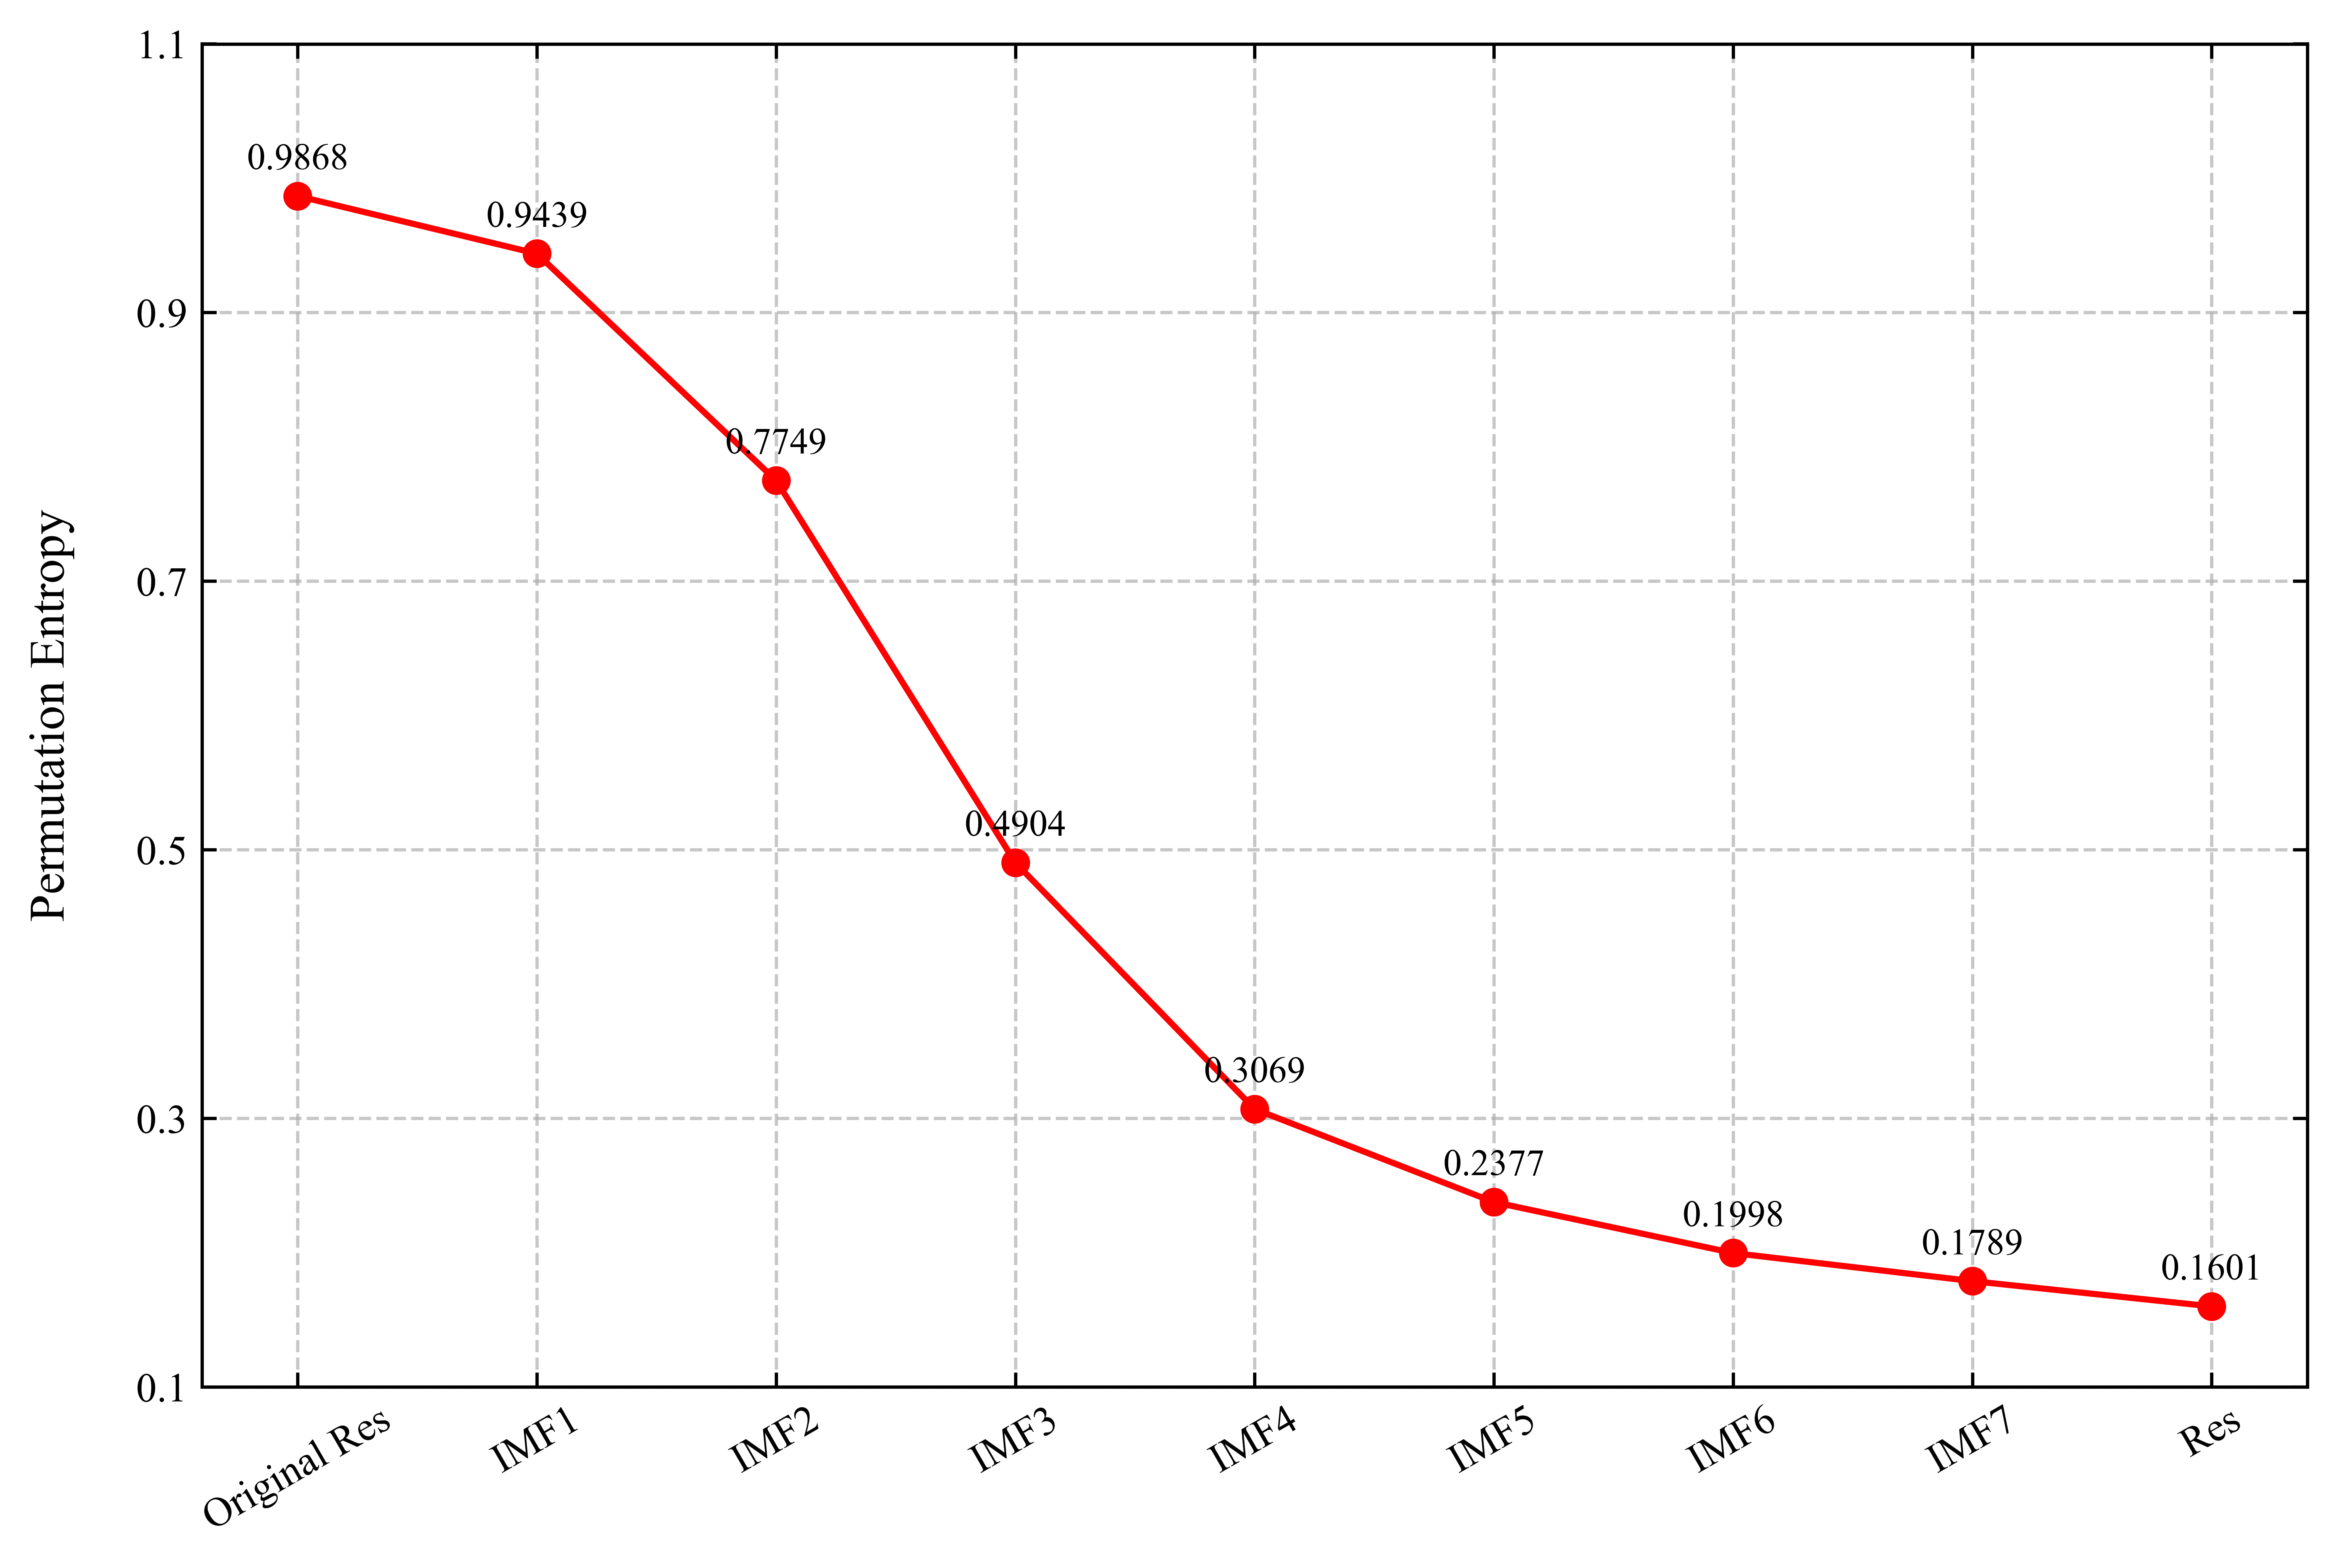

In [1]:
import numpy as np
import pandas as pd
import antropy as ant 
import matplotlib.pyplot as plt

plt.rc('font', family='Times New Roman')

order = 5  

raw_data = pd.read_csv('./SVMD_Residual.csv', index_col=0)
original_series = raw_data.values.flatten()

svmd_data = pd.read_csv('./REMD_IMFs.csv', index_col=0)

pe_results = {}

pe_results['Original Res'] = ant.perm_entropy(original_series, order=order, normalize=True)

for column in svmd_data.columns:
    sub_series = svmd_data[column].values
    pe_results[column] = ant.perm_entropy(sub_series, order=order, normalize=True)

# 4. 打印结果
print("Permutation Entropy of Subsequences:")
for k, v in pe_results.items():
    print(f"{k}: {v:.4f}")

keys = list(pe_results.keys())
values = list(pe_results.values())
keys[-1] = 'Res'  

plt.figure(figsize=(8.0, 5.4), dpi=1000)
plt.plot(keys, values, marker='o', linestyle='-', color="r")     
plt.ylabel('Permutation Entropy', fontsize=12, labelpad=15)
plt.ylim(0.1, 1.1)
plt.yticks(np.arange(0.1, 1.2, 0.2))
plt.tick_params(axis='x', direction='in', which='both', bottom=True, top=True, labelbottom=True)
plt.tick_params(axis='y', direction='in', which='both', left=True, right=True, labelleft=True)
plt.locator_params(axis='y', nbins=8)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.yticks(fontsize=10)
plt.xticks(rotation=30, fontsize=10)
for i, (key, value) in enumerate(pe_results.items()):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center', fontsize=9, color='black')
plt.tight_layout()
plt.savefig('REMD_WTI_PermutationEntropy.tif', format='tiff', dpi=1000, bbox_inches='tight')
plt.show()